Using numeric columns only:
['Root_DIR_Access', 'Temp_DIR_Access', 'Home_DIR_Access', 'User_DIR_Access', 'Sys_DIR_Access', 'Etc_DIR_Access', 'Other_DIR_Access', 'Total_Dependencies', 'Direct_Dependencies', 'Indirect_Dependencies', 'Local_IPs_Access', 'Remote_IPs_Access', 'Local_Port_Access', 'Remote_Port_Access']
Shape: (400, 14)


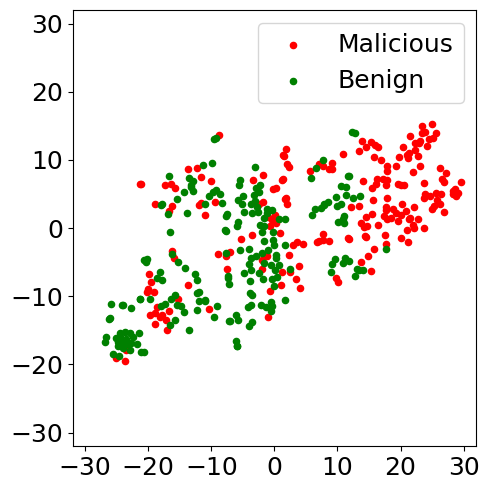

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import hstack

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

SEED = 42

df = pd.read_csv("metadata_dataset.csv")

benign_df = df[df["Level"] == 0].sample(n=200, random_state=SEED)
malicious_df = df[df["Level"] == 1].sample(n=200, random_state=SEED)

sampled_df = pd.concat([benign_df, malicious_df], axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)

y = sampled_df["Level"].values

drop_cols = [col for col in ["Package_Name", "Level"] if col in sampled_df.columns]
X = sampled_df.drop(columns=drop_cols)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
text_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Text columns:", text_cols)

# Numeric part
X_num = X[numeric_cols].fillna(0)
X_num_scaled = StandardScaler().fit_transform(X_num)

parts = [X_num_scaled]

# Text part
for col in text_cols:
    tfidf = TfidfVectorizer(max_features=200)
    X_text = tfidf.fit_transform(X[col].astype(str).fillna(""))
    parts.append(X_text)

# Merge all features
X_all = hstack(parts)

# TSNE works better on dense arrays for this size
X_all_dense = X_all.toarray() if hasattr(X_all, "toarray") else X_all

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED
)
X_tsne = tsne.fit_transform(X_all_dense)

# Plot
plt.figure(figsize=(5, 5))

plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1], c="red", s=20, label="Malicious")
plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1], c="green", s=20, label="Benign")

plt.xlim(-32, 32)
plt.ylim(-32, 32)

plt.legend(loc="upper right", fontsize=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.savefig("tsne_Metadata.png", dpi=600, bbox_inches="tight")
plt.show()

Numeric columns: ['Root_DIR_Access', 'Temp_DIR_Access', 'Home_DIR_Access', 'User_DIR_Access', 'Sys_DIR_Access', 'Etc_DIR_Access', 'Other_DIR_Access', 'Total_Dependencies', 'Direct_Dependencies', 'Indirect_Dependencies', 'Local_IPs_Access', 'Remote_IPs_Access', 'Local_Port_Access', 'Remote_Port_Access']
Text columns: ['Read_Processes', 'Write_Processes', 'Read_Data_Transfer', 'Write_Data_Transfer', 'File_Access_Processes', 'State_Transition', 'IO_Operations', 'File_Operations', 'Network_Operations', 'Time_Operations', 'Security_Operations', 'Process_Operations', 'Pattern_1', 'Pattern_2', 'Pattern_3', 'Pattern_4', 'Pattern_5', 'Pattern_6', 'Pattern_7', 'Pattern_8', 'Pattern_9', 'Pattern_10']


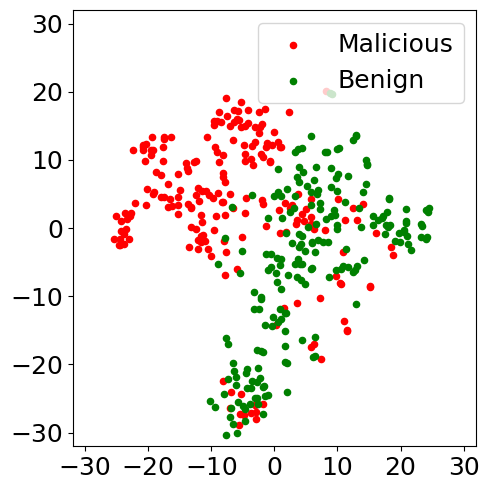

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import hstack

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

SEED = 42

df = pd.read_csv("static_dataset.csv")

benign_df = df[df["Level"] == 0].sample(n=200, random_state=SEED)
malicious_df = df[df["Level"] == 1].sample(n=200, random_state=SEED)

sampled_df = pd.concat([benign_df, malicious_df], axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)

y = sampled_df["Level"].values

drop_cols = [col for col in ["Package_Name", "Level"] if col in sampled_df.columns]
X = sampled_df.drop(columns=drop_cols)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
text_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Text columns:", text_cols)

# Numeric part
X_num = X[numeric_cols].fillna(0)
X_num_scaled = StandardScaler().fit_transform(X_num)

parts = [X_num_scaled]

# Text part
for col in text_cols:
    tfidf = TfidfVectorizer(max_features=200)
    X_text = tfidf.fit_transform(X[col].astype(str).fillna(""))
    parts.append(X_text)

# Merge all features
X_all = hstack(parts)

# TSNE works better on dense arrays for this size
X_all_dense = X_all.toarray() if hasattr(X_all, "toarray") else X_all

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED
)
X_tsne = tsne.fit_transform(X_all_dense)

# Plot
plt.figure(figsize=(5, 5))

plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1], c="red", s=20, label="Malicious")
plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1], c="green", s=20, label="Benign")

plt.xlim(-32, 32)
plt.ylim(-32, 32)

plt.legend(loc="upper right", fontsize=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.savefig("tsne_Static.png", dpi=600, bbox_inches="tight")
plt.show()

Numeric columns: ['Root_DIR_Access', 'Temp_DIR_Access', 'Home_DIR_Access', 'User_DIR_Access', 'Sys_DIR_Access', 'Etc_DIR_Access', 'Other_DIR_Access', 'Total_Dependencies', 'Direct_Dependencies', 'Indirect_Dependencies', 'Local_IPs_Access', 'Remote_IPs_Access', 'Local_Port_Access', 'Remote_Port_Access']
Text columns: ['Read_Processes', 'Write_Processes', 'Read_Data_Transfer', 'Write_Data_Transfer', 'File_Access_Processes', 'State_Transition', 'IO_Operations', 'File_Operations', 'Network_Operations', 'Time_Operations', 'Security_Operations', 'Process_Operations', 'Pattern_1', 'Pattern_2', 'Pattern_3', 'Pattern_4', 'Pattern_5', 'Pattern_6', 'Pattern_7', 'Pattern_8', 'Pattern_9', 'Pattern_10']
Processing text column: Read_Processes
Processing text column: Write_Processes
Processing text column: Read_Data_Transfer
Processing text column: Write_Data_Transfer
Processing text column: File_Access_Processes
Processing text column: State_Transition
Processing text column: IO_Operations
Processing

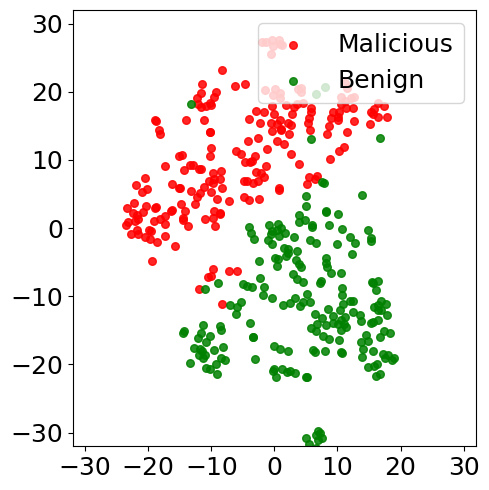

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import hstack

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

SEED = 42

df = pd.read_csv("QUT-DV25_dynamic_dataset.csv")

benign_df = df[df["Level"] == 0].sample(n=200, random_state=SEED)
malicious_df = df[df["Level"] == 1].sample(n=200, random_state=SEED)

sampled_df = pd.concat([benign_df, malicious_df], axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)

y = sampled_df["Level"].values

drop_cols = [col for col in ["Package_Name", "Level"] if col in sampled_df.columns]
X = sampled_df.drop(columns=drop_cols)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
text_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Text columns:", text_cols)

# Numeric part
X_num = X[numeric_cols].fillna(0)
X_num_scaled = StandardScaler().fit_transform(X_num)

parts = [X_num_scaled]

# Text part
for col in text_cols:
    tfidf = TfidfVectorizer(max_features=200)
    X_text = tfidf.fit_transform(X[col].astype(str).fillna(""))
    parts.append(X_text)

# Merge all features
X_all = hstack(parts)

# TSNE works better on dense arrays for this size
X_all_dense = X_all.toarray() if hasattr(X_all, "toarray") else X_all

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED
)
X_tsne = tsne.fit_transform(X_all_dense)

# Plot
plt.figure(figsize=(5, 5))

plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1], c="red", s=20, label="Malicious")
plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1], c="green", s=20, label="Benign")

plt.xlim(-32, 32)
plt.ylim(-32, 32)

plt.legend(loc="upper right", fontsize=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.savefig("tsne_Dynamic.png", dpi=600, bbox_inches="tight")
plt.show()